## Burn Scar Analysis with PACE and EMIT Data

Author: Skye Caplan (NASA, SSAI), Erik Bolch (USGS)

Last updated: 03/04/2026

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_data_access/
[emit-data-access]: https://nasa.github.io/VITALS/python/Exploring_EMIT_L2A_RFL.html

## Summary

This notebook will use the data downloaded from `01_Colocate_PACE_EMIT_data.ipynb` and preprocessed from `02_Align_PACE_EMIT_Grids.ipynb` to calculate the difference in normalized burn ratio (dNBR) over Southern California in response to fires which occurred in January 2025. We will demonstrate the complementary nature of PACE and EMIT observations, and how we can use their different temporal and spatial resolutions to our advantage. 

## Learning Objectives

At the end of this notebook, you will know how to:
- FILL OUT

## Contents
1. [Setup](#1.-Setup)
2. 

## 1. Setup

Begin by importing all of the packages used in this notebook.

In [25]:
import os
import cartopy
import rasterio 
import cf_xarray 
import numpy as np 
import xarray as xr 
import rioxarray as rio
import cartopy.crs as ccrs 
import matplotlib.pyplot as plt 

os.chdir(os.path.abspath(os.path.join(get_ipython().starting_dir, os.pardir)))
from modules import pace_tools as pace
from modules import emit_tools as emit

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

In the previous notebook tutorial, `02_Align_PACE_EMIT_Grid.ipynb`, we gridded, subset, and saved PACE and EMIT surface reflectance datasets to a region of interest around the January 2025 Southern California wildfires. Those data will be used for this tutorial, so please go through that content to generate the datasets for this tutorial if you have not already. If you have, you'll recall we exported the subset data to the `subset_data` directory - if you chose to export to your own directory, please replace the paths in the next cell with your path to the same files.

Since our data are already gridded, we won't need to use the EMIT or PACE tools to open and project them again. Instead, we can just load them as `xarray` datasets.

In [27]:
emit_paths = ["emit_pace/subset_data/emit_prefire.nc",
              "emit_pace/subset_data/emit_postfire.nc"]
oci_paths = [ "emit_pace/subset_data/oci_prefire.nc",
              "emit_pace/subset_data/oci_postfire.nc"]

emit_prefire = xr.open_dataset(emit_paths[0])
emit_postfire = xr.open_dataset(emit_paths[1])
oci_prefire = xr.open_dataset(oci_paths[0])
oci_postfire = xr.open_dataset(oci_paths[1])

### 2. Preparing Data for NBR
For this case study, we'll be investigating fires that occurred in January of 2025 in the Los Angeles area of Southern California using the Normalized Burn Ratio (NBR). NBR is a multispectral vegetation index that neither EMIT nor PACE puts out as a product, but can be calculated with their surface reflectance bands using the equation below:
$$NBR = \frac{NIR - SWIR}{NIR+SWIR}$$

The difference in NBR (dNBR) in time can be used to delineate burn scars in an area. dNBR is calculated as $dNBR = NBR_{prefire} - NBR_{postfire}$

We've defined a function below to calculate the NBR with our two datasets.

In [28]:
def calc_nbr(ds, wvl_var=None):
    """
    Calculates Normalized Burn Ratio given reflectance data
    Args:
        ds - reflectance dataset with wavelength info as a coordinate
        wvl_var - str name of wavelength variable. Will attempt to find it if
                  none given
    Returns:
        nbr - NBR dataset
    """
    # Get wavelength dimension name for selection
    for dim in list(ds.dims):
        if "wavelength" in dim:
            wvl_var = dim
            break
        else:
            continue
    
    # Calculate NBR
    if wvl_var is None:
        print("Could not find wavelength variable, please provide the variable name in the function call")
        return None
    else:
        nir = ds.sel({f"{wvl_var}":870}, method="nearest")
        swir = ds.sel({f"{wvl_var}":2131}, method="nearest")
        nbr = ((nir - swir) / (nir + swir))
        # TODO: set attrs here too
        return xr.Dataset({"nbr":nbr})

In [30]:
oci_prefire_nbr = calc_nbr(oci_prefire["rhos"])
oci_postfire_nbr = calc_nbr(oci_postfire["rhos"])
emit_prefire_nbr = calc_nbr(emit_prefire["reflectance"])
emit_postfire_nbr = calc_nbr(emit_postfire["reflectance"])

Now, the dNBR can be calculated to assess burn scars in the area.

In [32]:
oci_dnbr = oci_prefire_nbr - oci_postfire_nbr
oci_dnbr = oci_dnbr.rename({"nbr":"dnbr"})

emit_dnbr_data = emit_prefire_nbr.nbr.data - emit_postfire_nbr.nbr.data
emit_dnbr = xr.Dataset(
    data_vars=dict(dnbr=(["latitude", "longitude"], emit_dnbr_data)),
    coords=dict(latitude=emit_postfire.latitude, longitude=emit_postfire.longitude)
)

# TODO: Figure out why the below doesn't work but above does?
#emit_dnbr = emit_prefire_nbr.nbr - emit_postfire_nbr.nbr
#emit_dnbr = emit_dnbr.rename({"nbr":"dnbr"})

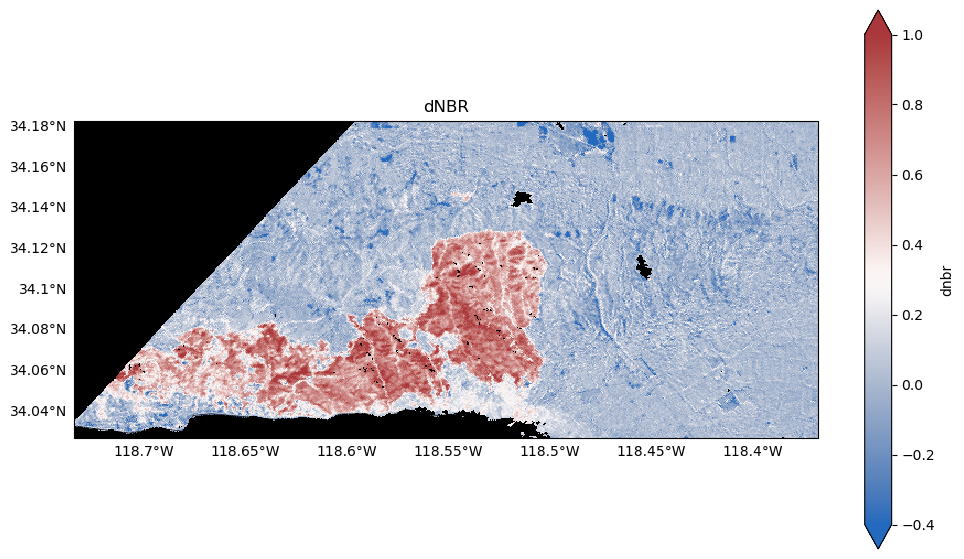

In [33]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(12, 7), subplot_kw={"projection": ccrs.PlateCarree()})
emit_dnbr.dnbr.plot(vmin=-0.4, vmax=1, cmap=sns.color_palette("vlag", as_cmap=True))
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25, alpha=0)
ax.coastlines(linewidth=0.5)
ax.set_facecolor('k')
ax.set_title("dNBR")
plt.show()